In [6]:
# Section 1: Business Understanding
# **Client:** Logistics Company
# **Problem:** Lack of visibility into delivery delays, operational bottlenecks, and logistics costs.
# **Objective:** Analyze operational data to identify patterns, calculate KPIs, and recommend improvements.

In [7]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../')
from src.data_loader import load_data
from src.data_cleaner import clean_data
from src.business_analysis import *
from src.visualization import *

In [8]:
# # Section 3: Load Data
df = load_data(r'E:\logistics_delivery_analytics\data\raw\logistics_data.csv')

In [9]:
# # Section 4: Basic Data Understanding
print(df.shape)
display(df.head())
df.info()
display(df.describe())

(5000, 22)


,order_id,customer_id,order_date,warehouse,origin_city,destination_city,distance_km,product_category,quantity,weight_kg,...,shipping_cost,fuel_cost,warehouse_processing_hours,dispatch_date,expected_delivery_date,actual_delivery_date,delivery_status,customer_rating,damage_flag,return_flag
0,ORD101253,CUST12780,2025-03-12,Bengaluru,Bengaluru,Chennai,451.7,Home & Kitchen,7,5.51,...,2044.56,381.66,8.36,2025-03-14,2025-03-19,2025-03-24,Delayed,3.0,No,No
1,ORD102838,CUST11842,2025-12-02,Delhi,Delhi,Surat,592.8,Automotive,1,1.05,...,2582.70,385.02,10.33,2025-12-05,2025-12-12,2025-12-12,Delivered,4.0,No,No
2,ORD103457,CUST10940,2025-04-21,Pune,Pune,Nagpur,191.9,Clothing,3,9.09,...,817.23,185.83,8.88,2025-04-23,2025-04-28,2025-04-28,Delivered,5.0,No,No
3,ORD100061,CUST10263,2025-02-21,Pune,Pune,Coimbatore,376.4,Clothing,7,1.34,...,1713.22,386.35,10.18,2025-02-24,2025-03-02,2025-03-04,Delayed,3.0,No,No
4,ORD103947,CUST12467,2025-08-22,Mumbai,Mumbai,Delhi,895.3,Sports,5,3.95,...,3980.06,990.42,11.17,2025-08-24,2025-08-30,2025-08-30,Delivered,4.0,No,No


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_id                    5000 non-null   object 
 1   customer_id                 5000 non-null   object 
 2   order_date                  5000 non-null   object 
 3   warehouse                   5000 non-null   object 
 4   origin_city                 5000 non-null   object 
 5   destination_city            4960 non-null   object 
 6   distance_km                 5000 non-null   float64
 7   product_category            5000 non-null   object 
 8   quantity                    5000 non-null   int64  
 9   weight_kg                   5000 non-null   float64
 10  shipping_mode               5000 non-null   object 
 11  delivery_partner            5000 non-null   object 
 12  shipping_cost               4950 non-null   float64
 13  fuel_cost                   4950 

,distance_km,quantity,weight_kg,shipping_cost,fuel_cost,warehouse_processing_hours,customer_rating
count,5000.000000,5000.000000,5000.000000,4950.000000,4950.000000,4941.000000,4911.000000
mean,411.098620,3.967000,5.528694,2286.791669,373.230737,8.391716,4.124822
std,260.537306,2.009955,3.921885,1682.276034,246.607318,2.306332,0.711340
min,-25.000000,0.000000,0.200000,-100.000000,20.000000,2.000000,2.000000
25%,221.775000,2.000000,2.700000,1141.012500,194.930000,6.810000,4.000000
50%,354.350000,4.000000,4.640000,1808.200000,319.115000,8.380000,4.000000
75%,541.800000,6.000000,7.422500,2906.355000,497.037500,10.020000,5.000000
max,1800.000000,7.000000,34.090000,16275.330000,1755.710000,15.650000,5.000000


In [10]:
# # Section 5: Data Quality
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated(subset=['order_id']).sum())

Missing values:
 order_id                       0
customer_id                    0
order_date                     0
warehouse                      0
origin_city                    0
destination_city              40
distance_km                    0
product_category               0
quantity                       0
weight_kg                      0
shipping_mode                  0
delivery_partner               0
shipping_cost                 50
fuel_cost                     50
warehouse_processing_hours    59
dispatch_date                  0
expected_delivery_date         0
actual_delivery_date           0
delivery_status                0
customer_rating               89
damage_flag                    0
return_flag                    0
dtype: int64
Duplicates: 25


In [11]:
# # Section 6: Data Cleaning & Section 7: Derived Columns
df_clean = clean_data(df)

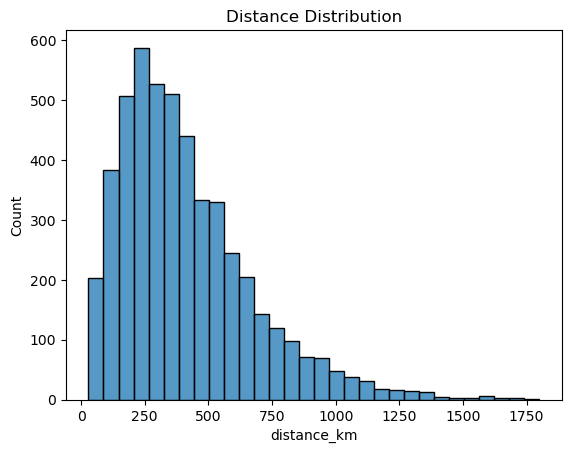

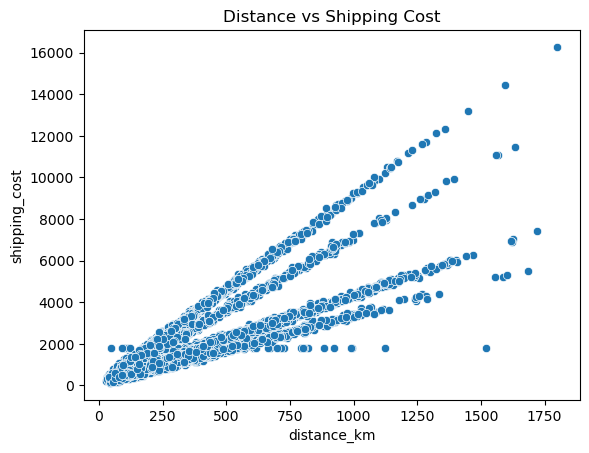

In [12]:
# # Section 8: EDA (Univariate, Bivariate, Multivariate)
sns.histplot(df_clean['distance_km'], bins=30)
plt.title("Distance Distribution")
plt.show()

sns.scatterplot(data=df_clean, x='distance_km', y='shipping_cost')
plt.title("Distance vs Shipping Cost")
plt.show()

In [13]:
# # Section 9: KPI Analysis & Section 10: Business Analysis
print(f"Total Orders: {calculate_total_orders(df_clean)}")
print(f"On-Time %: {calculate_on_time_percentage(df_clean):.2f}%")
print(f"Total Logistics Cost: ${calculate_total_logistics_cost(df_clean):.2f}")

Total Orders: 4963
On-Time %: 100.00%
Total Logistics Cost: $13173510.98


e:\logistics_delivery_analytics\notebooks\..\src\visualization.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='delivery_status', ax=ax, palette='viridis')


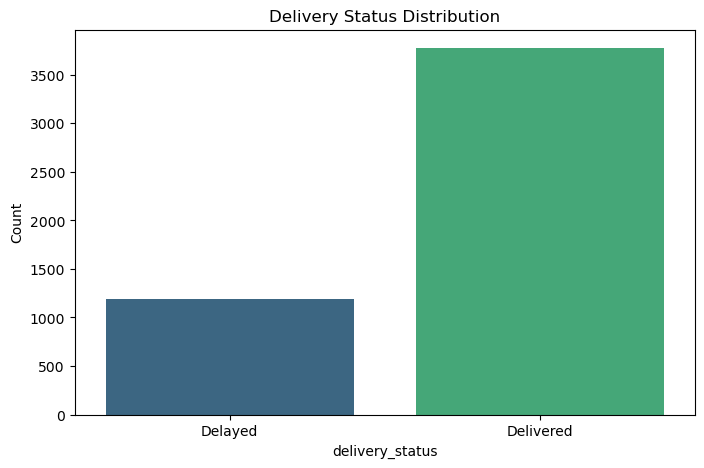

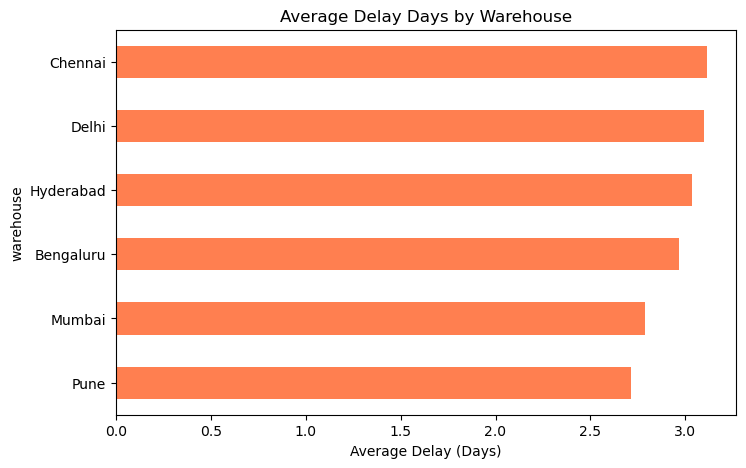

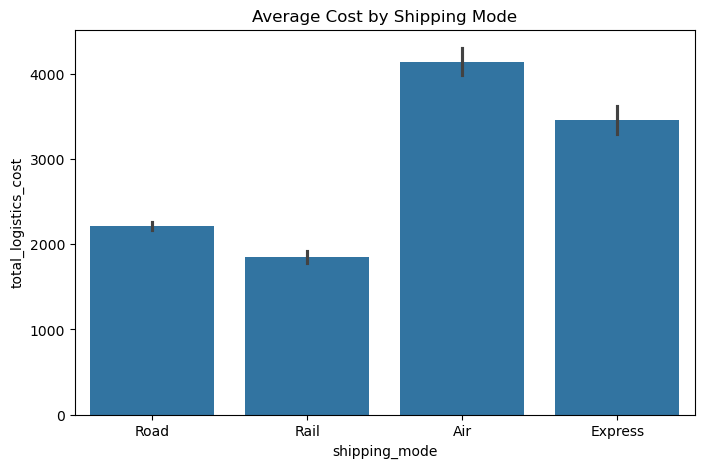

In [14]:
# # Section 11: Visualization
plot_delivery_status(df_clean)
plt.show()
plot_delay_by_warehouse(df_clean)
plt.show()
plot_cost_by_shipping_mode(df_clean)
plt.show()

In [15]:
# # Section 12: Business Insights & Section 13: Recommendations
# **Finding:** Certain warehouses exhibit significantly higher delay percentages.
# **Business Meaning:** Operational bottlenecks in processing time directly impact final delivery timelines.
# **Recommendation:** Audit operations in underperforming warehouses to streamline dispatch procedures.